# Third practical work in Deep Learning course 
**Name:** Maha Kahla 


**Purpose of the laboratory work:** To learn the process of working with recurrent neural networks (RNNs), including LSTM and GRU, using time series analysis as example. Learn to predict future time series values.

The first thing we have to do is importing the necessary libraries that include the tools we need to implement the tasks

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import DataLoader

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


The following code we use to mount google drive so we can download dataset directly to drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
cd drive/My\ Drive/

/content/drive/My Drive


For this task we use the time series humidity from weather dataset, which contains hourly measurement data in different cities. However, in this task I only used the humidity file and analyzed the data for "Vancouver", any of the rest will be the same.

After uploading the dataset to drive, we need to read the csv file using pandas library. We display the first few rows of the file.

In [5]:
dataset = pd.read_csv("/content/drive/MyDrive/humidity.csv")
dataset.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
1,2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2,2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
3,2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
4,2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


In the following code we plot the values of humidity in two cities, and during a specific period of time in order to make the graph clearer.

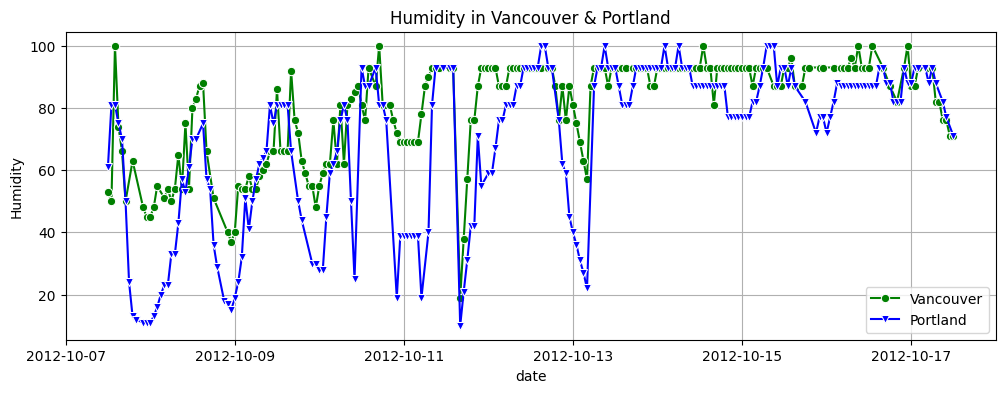

In [6]:
dataset["datetime"] = pd.to_datetime(dataset["datetime"])
d_filtered = dataset[(dataset["datetime"] >= "2012-10-07 12:00:00") & (dataset["datetime"] <= "2012-10-17 12:00:00")]
# plotting
plt.figure(figsize=(12, 4))
sns.lineplot(x=d_filtered["datetime"], y=d_filtered["Vancouver"], marker="o",color =  'green', label="Vancouver")
sns.lineplot(x=d_filtered["datetime"], y=d_filtered["Portland"], marker="v", color = 'blue' , label="Portland")
plt.title("Humidity in Vancouver & Portland")
plt.ylabel("Humidity")
plt.xlabel("date")
plt.legend()
plt.grid()
plt.show()

Since we from the table that there are some values with Nan, so we need to do prepocessing to get rid of such data. The following code removes NaN (missing values) and converts it into a NumPy array, also reshapes it into a 2D array which is required for (MinMaxScaler), finally, it normalizes the "Vancouver" column in a dataset using MinMax Scaling from sklearn.preprocessing. It ensures that the values are transformed into a range between 0 and 1.

In [7]:
from sklearn.preprocessing import MinMaxScaler

column = dataset["Vancouver"].dropna().values.reshape(-1,1)
scaled_data = MinMaxScaler(feature_range=(0, 1)).fit_transform(column)

display(scaled_data)

array([[0.72727273],
       [0.72727273],
       [0.72727273],
       ...,
       [0.79545455],
       [0.85227273],
       [0.85227273]])

In the next step we divide the data into training, validation and testing datasets. We use train_test_split from sklearn.model_selection to split a dataset (column) into three parts. We firstly divided the original column then created 3 datasets from the scaled data. The output shows the sizes of every dataset.

In [8]:
from sklearn.model_selection import train_test_split

train, re = train_test_split(column, test_size=0.3, shuffle=False)
valid, test = train_test_split(re, test_size=0.5, shuffle=False)

train_len = int(len(train))
valid_len = int(len(valid))
test_len = int(len(test))

train, valid, test = scaled_data[:train_len], scaled_data[train_len:train_len + valid_len], scaled_data[train_len + valid_len:]

print(f"Train: {len(train)}, Valid: {len(valid)}, Test: {len(test)}")

Train: 30398, Valid: 6514, Test: 6515


The following code prepares the data for training a recurrent neural network (RNN) by creating sequences of data points and reshaping the data into the format required by RNNs. The function create_sequences returns two arrays: sequence1 (features) and sequence2 (targets), both converted to NumPy arrays for efficient processing. In each sequence we store the windows of data, where each window consists of window_size points. The reshaping of arrays into 3D arrays is required for RNN: the first dimension is the number of sequences,the second is the length of each sequence and the third is the number of features at each timestep and in this case, it’s just one feature.

In [9]:
def create_sequences(data, window_size=10):
    sequence1 , sequence2 = [] , []
    for i in range(len(data) - window_size):  # Ensures we stay within bounds
        sequence1.append(data[i:i + window_size])  # Extract window
        sequence2.append(data[i + window_size])
    return np.array(sequence1) , np.array(sequence2) # Convert to NumPy array for efficient processing


trainS , trainS_y = create_sequences(train, window_size=50)
validS , validS_y = create_sequences(valid, window_size=50)
testS , testS_y = create_sequences(test, window_size=50)

print("Shape of sequences:", trainS.shape)
print("First sequence:\n", trainS[0])


X_train = trainS.reshape((trainS.shape[0], trainS.shape[1], 1))
X_valid = validS.reshape((validS.shape[0], validS.shape[1], 1))
X_test = testS.reshape((testS.shape[0], testS.shape[1], 1))

Shape of sequences: (30348, 50, 1)
First sequence:
 [[0.72727273]
 [0.72727273]
 [0.72727273]
 [0.73863636]
 [0.75      ]
 [0.75      ]
 [0.76136364]
 [0.76136364]
 [0.77272727]
 [0.78409091]
 [0.78409091]
 [0.79545455]
 [0.80681818]
 [0.80681818]
 [0.81818182]
 [0.81818182]
 [0.82954545]
 [0.84090909]
 [0.84090909]
 [0.85227273]
 [0.85227273]
 [0.86363636]
 [0.875     ]
 [0.875     ]
 [0.88636364]
 [0.89772727]
 [0.875     ]
 [0.72727273]
 [0.72727273]
 [0.625     ]
 [0.52272727]
 [0.46590909]
 [0.39772727]
 [0.375     ]
 [0.45454545]
 [0.42045455]
 [0.51136364]
 [0.68181818]
 [0.72727273]
 [0.80681818]
 [0.85227273]
 [0.72727273]
 [0.78409091]
 [0.77272727]
 [0.78409091]
 [0.80681818]
 [0.82954545]
 [0.85227273]
 [0.85227273]
 [0.82954545]]


The next step is to create the model, we used gated Recurrent Unit, which is a type of recurrent neural network designed for sequential data prediction. In the GRU model, we define a GRU layer with the following parameters: input_size specifies the number of input features per timestep, hidden_size is the number of hidden units in the GRU, which controls the model’s capacity to learn from the sequence. Additionally, a dropout layer is added with a dropout rate of 20% which is used to prevent overfitting by randomly setting a fraction of the input units to zero during training. Also, fully connected layer is used to transform the hidden state output from the GRU to the required output size because the task is a regression problem predicting a single value.

We set the model parameters, a higher value of hidden units of GRU means the model has more capacity to learn complex patterns. The used loss function is mean squared error, which is commonly used for regression problems. The Adam optimizer is used to update the model parameters during training. 

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Define the GRU model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, hidden = self.gru(x)
        x = self.dropout(hidden[-1])
        x = self.fc(x)
        return x

# Model parameters
input_size = 1
hidden_size = 64
output_size = 1


model = GRUModel(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


We created the typical function train_modelto train a PyTorch model on training data and validate it using validation data over a specified number of epochs. It tracks the loss during both training and validation and prints the results periodically.

In [11]:
def train_model(model, train_loader, val_loader, epochs):
    loss_plot = []
    val_loss_plot = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_plot.append(avg_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                val_outputs = model(X_val)
                val_loss += criterion(val_outputs, y_val).item()
        avg_val_loss = val_loss / len(val_loader)
        val_loss_plot.append(avg_val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f}, Val_loss={avg_val_loss:.4f}")

    return loss_plot, val_loss_plot

In [12]:
print(type(X_train))

<class 'numpy.ndarray'>


In [13]:
y_train = trainS_y
y_valid = validS_y

In order to implement the training process we need to convert data to tensors and create the dataloaders as follows.

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(trainS_y, dtype=torch.float32)

X_valid = torch.tensor(X_valid, dtype=torch.float32)
y_valid = torch.tensor(validS_y, dtype=torch.float32)

In [15]:
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

train_data = torch.utils.data.TensorDataset(X_train, y_train)
val_data = torch.utils.data.TensorDataset(X_valid, y_valid)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False)


In [16]:
# Train the model
loss_plot, val_loss_plot = train_model(model, train_loader, val_loader, epochs=50)

Epoch 10/50: Loss=0.0088, Val_loss=0.0124
Epoch 20/50: Loss=0.0080, Val_loss=0.0121
Epoch 30/50: Loss=0.0075, Val_loss=0.0122
Epoch 40/50: Loss=0.0073, Val_loss=0.0120
Epoch 50/50: Loss=0.0069, Val_loss=0.0118


In the following code we evaluate the model on the test dataset and we calculate the metrics.

In [17]:
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(testS_y, dtype=torch.float32)

In [18]:
print(X_test.shape)

torch.Size([6465, 50, 1])


In [19]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(y_train.reshape(-1, 1))

MinMaxScaler()

In [20]:
# Evaluate model
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
predictions = scaler.inverse_transform(predictions)

mse = mean_squared_error(y_test_rescaled, predictions)
mae = mean_absolute_error(y_test_rescaled, predictions)
rmse = math.sqrt(mse)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MSE: 0.009133796009168452
MAE: 0.06713902777623626
RMSE: 0.09557089519915805


The evaluation metrics indicate a fairly low error, mse measures the average squared difference between predicted and actual values and it penalizes larger deviations more heavily and a lower value indicates better performance. mae represents the average absolute difference between predicted and actual values, it does not square errors, so it is easier to interpret. A value of 0.0677 suggests that, on average, the model’s predictions are off by about 0.0677 units. rmse is the square root of mse, making it more interpretable because it's in the same units as the original data.

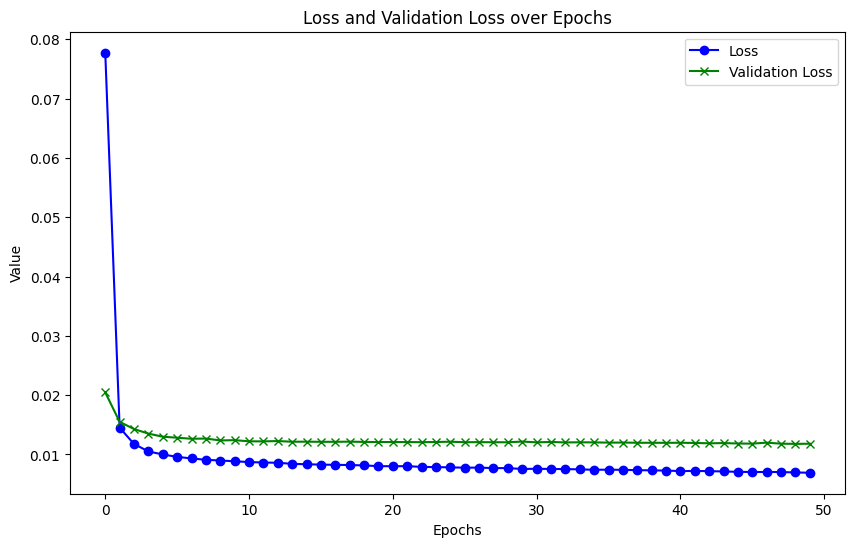

In [21]:
# Plot loss
epochs_plot = list(range(len(loss_plot)))
plt.figure(figsize=(10, 6))
plt.plot(epochs_plot, loss_plot, label='Loss', color='blue', marker='o')
plt.plot(epochs_plot, val_loss_plot, label='Validation Loss', color='green', marker='x')
plt.title('Loss and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()


We notice that both training and validation losses drop significantly in the first few epochs, indicating that the model is learning and improving at the start. The blue curve (training loss) keeps decreasing consistently, which is expected as the model optimizes itself.

We finally plot actual vs. predicted values which helps visually inspect if predictions closely follow the real trend.

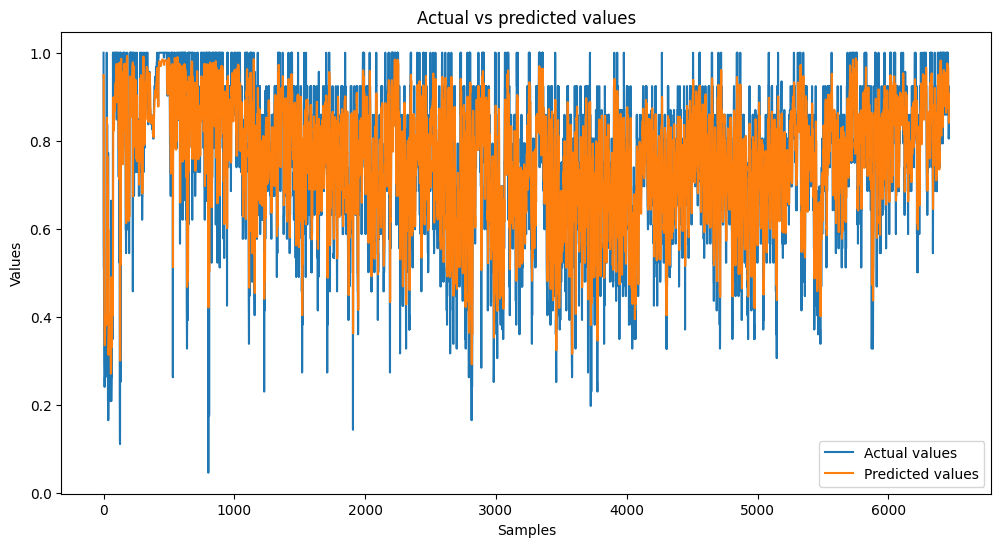

In [22]:

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual values')
plt.plot(predictions, label='Predicted values')
plt.title('Actual vs predicted values')
plt.xlabel('Samples')
plt.ylabel('Values')
plt.legend()
plt.show()

We can see that predictions follow the actual trend but with a variance. here is a lot of noise, and it seems the model struggles with capturing finer details. There are noticeable gaps where actual values are lower, but predicted values remain high.

Possible improvements:  Improving model generalization by increasing dropout rate to prevent overfitting, also, smoothing the predictions by applying moving averages to smooth out fluctuations or using a larger window size in sequence creation to give the model more context.